In [76]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

### **Read data from excel files**

In [77]:
df = pd.read_excel("data/dataset_young.xlsx")

In [78]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [79]:
df.shape

(20096, 13)

In [80]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [81]:
df.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


### **Data Cleaning & Exploratory Data Analysis**

#### **Handling Missing Values**

In [82]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [83]:
df.dropna(inplace=True)

In [84]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

#### **Handling Duplicates**

In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.drop_duplicates(inplace=True)

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


#### **Data Cleaning: number_of_dependants**

In [89]:
df[df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-3, -1])

In [90]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

In [91]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


### **1. Numeric Columns**

In [92]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

In [93]:
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

#### **Outlier Treatment: Age Column**

In [94]:
df[df['age']>100]['age'].unique()

array([], dtype=int64)

In [95]:
df1 = df[df.age<=100]

In [96]:
df1.age.describe()

count    20090.000000
mean        21.494375
std          2.294052
min         18.000000
25%         19.000000
50%         22.000000
75%         23.000000
max         25.000000
Name: age, dtype: float64

#### **Outlier Treatment: Income Column**

In [97]:
quantile_thresold = df1.income_lakhs.quantile(0.999)

In [98]:
quantile_thresold

np.float64(100.0)

In [99]:
df1[df1.income_lakhs>quantile_thresold].shape

(4, 13)

In [100]:
df2 = df1[df1.income_lakhs<=quantile_thresold].copy()

In [101]:
df2.shape

(20086, 13)

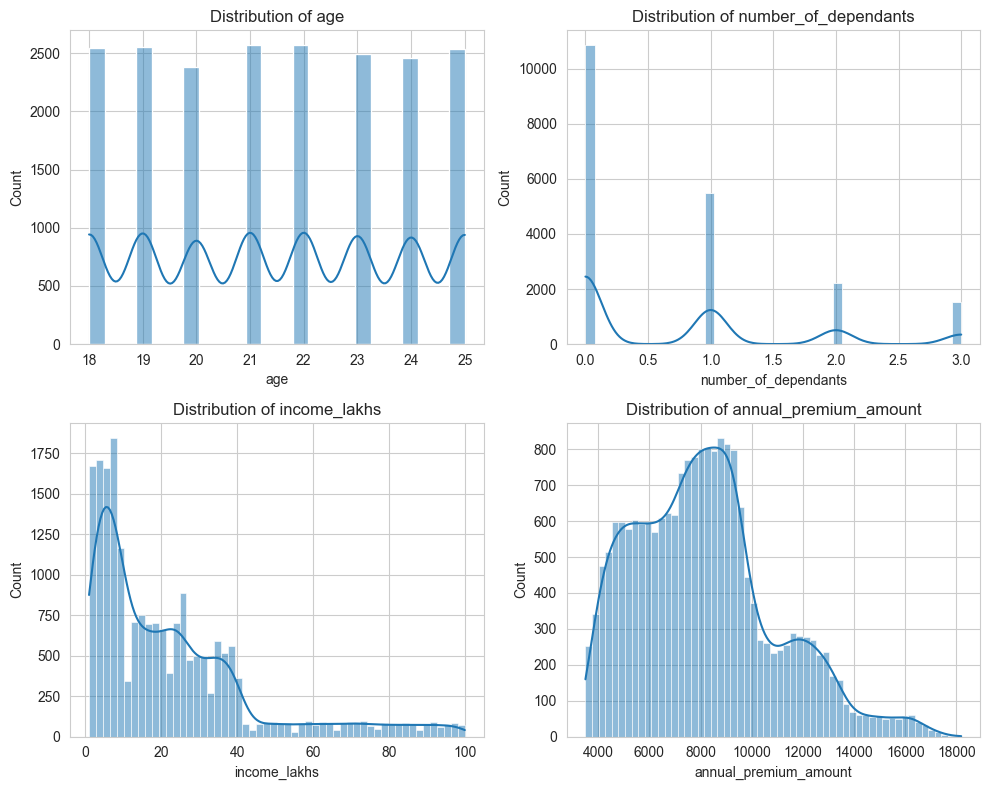

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=df2,x=column,kde=True,ax=ax)

    ax.set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

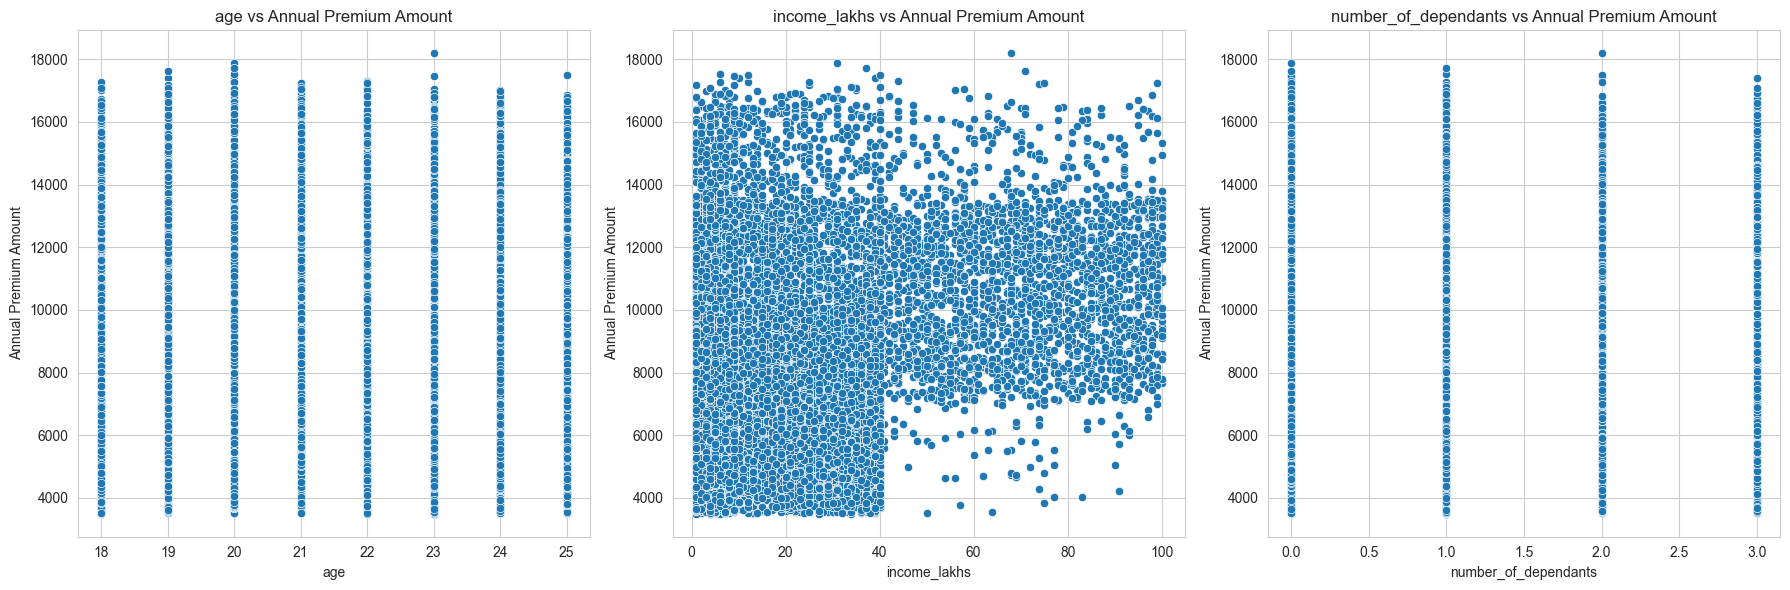

In [103]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1,len(numeric_features),figsize=(18, 6))

for ax, column in zip(axes, numeric_features):

    sns.scatterplot(data=df2,x=column,y='annual_premium_amount',ax=ax)

    ax.set_title(f'{column} vs Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()
plt.show()

### **2. Categorical Columns**

In [104]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


In [105]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})
df2['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

### **Feature Engineering**

In [106]:
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


#### **Calculate Risk Score**

In [107]:
# Define risk scores for each medical condition
risk_scores = {'diabetes': 6,'heart disease': 8,'high blood pressure': 6,'thyroid': 5,'no disease': 0,'none': 0}

# Split medical history into separate conditions
df2[['disease1', 'disease2']] = (df2['medical_history'].str.lower().str.split(' & ', expand=True))

# Handle missing values
df2[['disease1', 'disease2']] = (df2[['disease1', 'disease2']].fillna('none'))

# Calculate total risk score
diseases = ['disease1', 'disease2']

df2['total_risk_score'] = sum(df2[disease].map(risk_scores)for disease in diseases)

# Normalize risk score to a range of 0–1
df2['normalized_risk_score'] = (
    (df2['total_risk_score'] - df2['total_risk_score'].min()) / (df2['total_risk_score'].max() - df2['total_risk_score'].min()))

df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,no disease,none,0,0.000000


#### **Encode Text Columns**

In [108]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Gold': 3,'Silver': 2,'Bronze': 1})

In [109]:
df2.income_level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [110]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [111]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

In [112]:
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [113]:
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,no disease,none,0,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,no disease,none,0,...,1,0,1,0,1,0,0,0,0,0


In [114]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20086 entries, 0 to 20095
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              20086 non-null  int64  
 1   number_of_dependants             20086 non-null  int64  
 2   income_level                     20086 non-null  int64  
 3   income_lakhs                     20086 non-null  int64  
 4   medical_history                  20086 non-null  object 
 5   insurance_plan                   20086 non-null  int64  
 6   annual_premium_amount            20086 non-null  int64  
 7   disease1                         20086 non-null  object 
 8   disease2                         20086 non-null  object 
 9   total_risk_score                 20086 non-null  int64  
 10  normalized_risk_score            20086 non-null  float64
 11  gender_Male                      20086 non-null  int64  
 12  region_Northwest       

#### **Feature Selection**

In [115]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)

In [116]:
df4.head(5)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


#### **Calculate VIF for Multicolinearity**

In [117]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

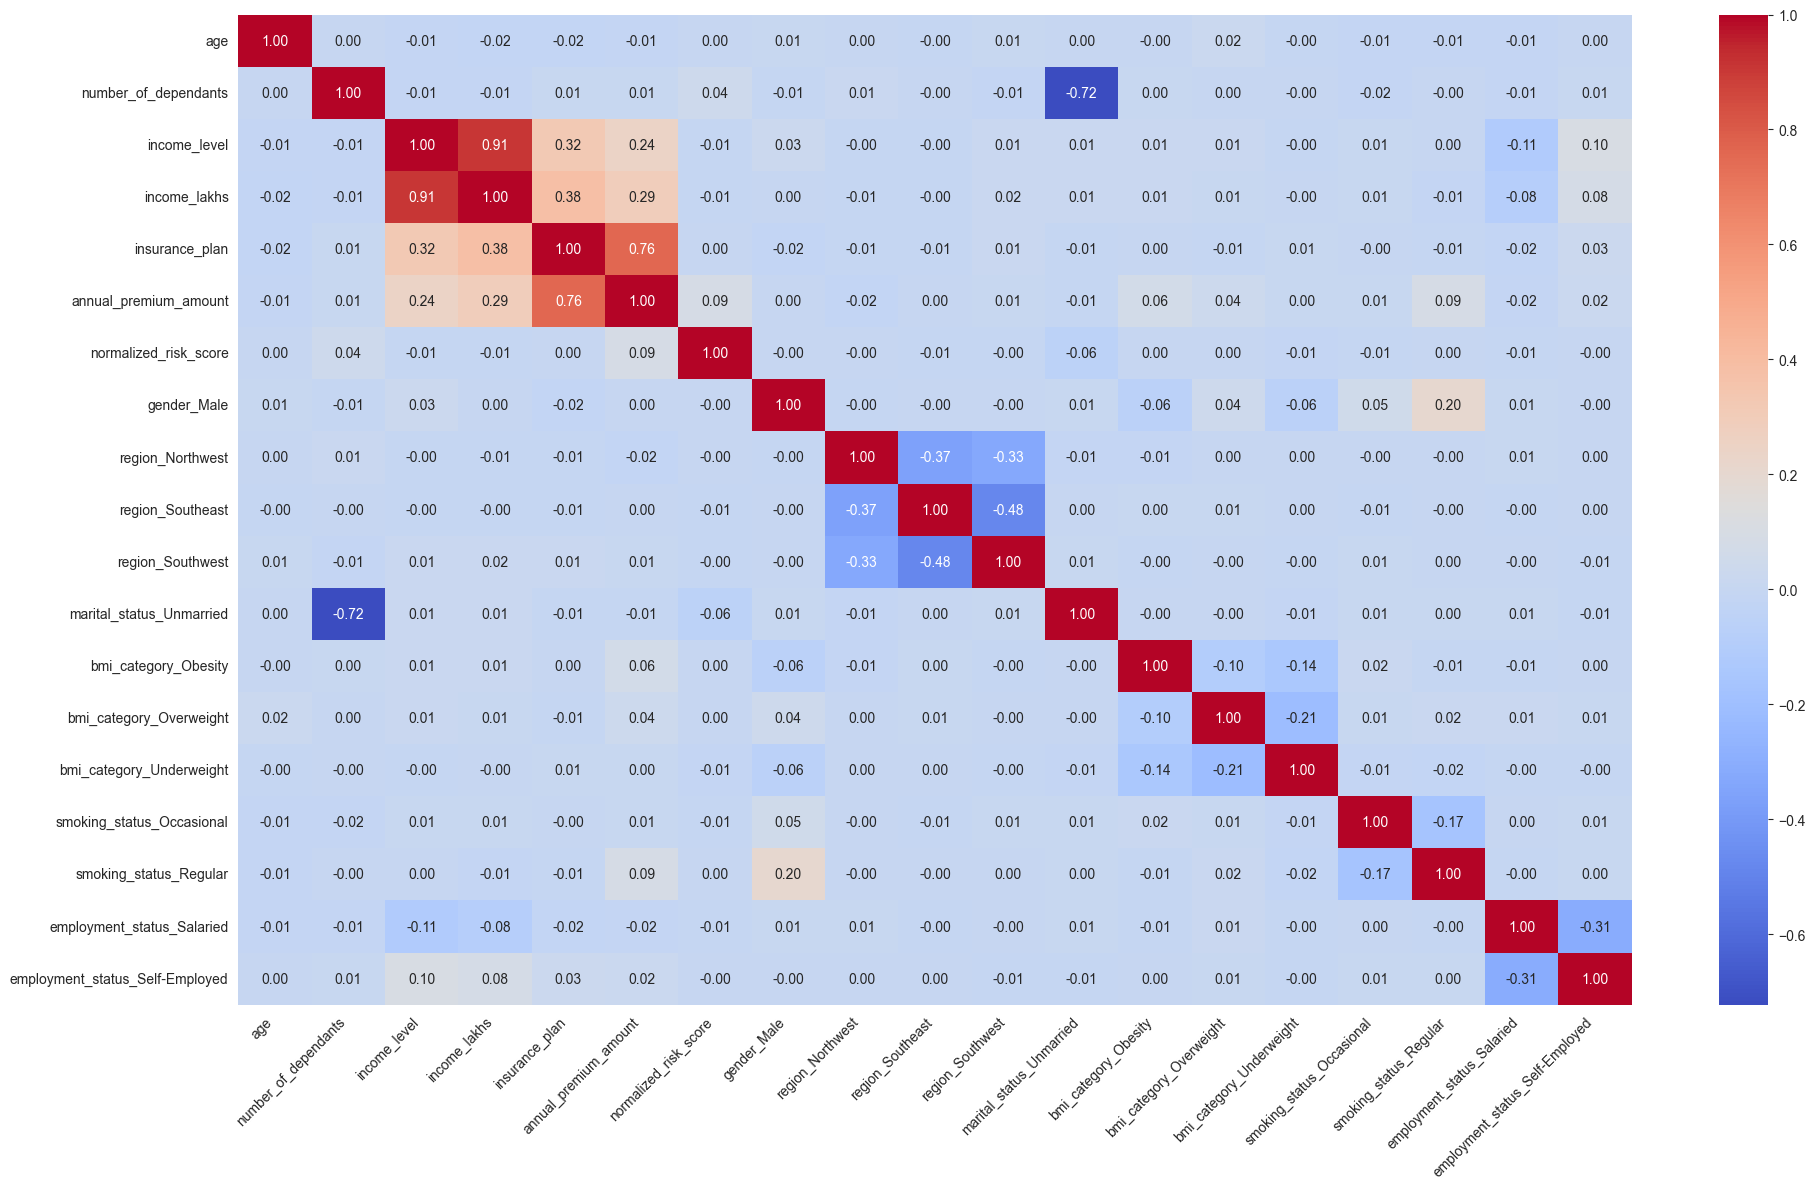

In [118]:
correlation_matrix = df4.corr()

plt.figure(figsize=(20, 12))

sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [119]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):

    vif_df = pd.DataFrame({
        'Column': data.columns,
        'VIF': [
            variance_inflation_factor(data.values, i)
            for i in range(data.shape[1])
        ]
    })

    return vif_df.sort_values(
        by='VIF',
        ascending=False
    ).reset_index(drop=True)

In [120]:
from sklearn.preprocessing import MinMaxScaler

X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

cols_to_scale = ['age','number_of_dependants','income_level','income_lakhs','insurance_plan']

scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(
    X[cols_to_scale]
)

X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [121]:
calculate_vif(X)

,Column,VIF
0,income_level,11.928707
1,income_lakhs,11.874242
2,marital_status_Unmarried,7.326373
3,age,3.142881
4,region_Southeast,2.970188
5,region_Southwest,2.730503
6,gender_Male,2.310023
7,region_Northwest,2.147701
8,number_of_dependants,1.860761
9,employment_status_Salaried,1.672615


In [122]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,marital_status_Unmarried,7.299818
1,age,3.141534
2,region_Southeast,2.968993
3,region_Southwest,2.729813
4,gender_Male,2.299848
5,income_lakhs,2.291873
6,region_Northwest,2.146767
7,number_of_dependants,1.858110
8,employment_status_Salaried,1.666719
9,insurance_plan,1.587794


In [123]:
# we will drop income_lakhs due to high VIF value
X_reduced = X.drop('income_level', axis="columns")

### **Model Training**

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (14060, 17)
x test:  (6026, 17)
y train:  (14060,)
y test:  (6026,)


#### **Linear Regression Model**

In [125]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.6020471274164894, 0.6047589163893643)

In [126]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  3005669.8791236724 RMSE:  1733.6867880686154


In [127]:
X_test.shape

(6026, 17)

In [128]:
np.set_printoptions(suppress=True, precision=6)

In [129]:
model_lr.coef_

array([  55.190515, -145.039643,  -36.066768, 7000.070416, 1111.278786,
          9.825648, -114.27345 ,  -36.466371,  -67.223225,  -58.534342,
        792.95266 ,  435.760406,  169.728916,  244.813937,  619.082947,
        -13.053549,   -4.342722])

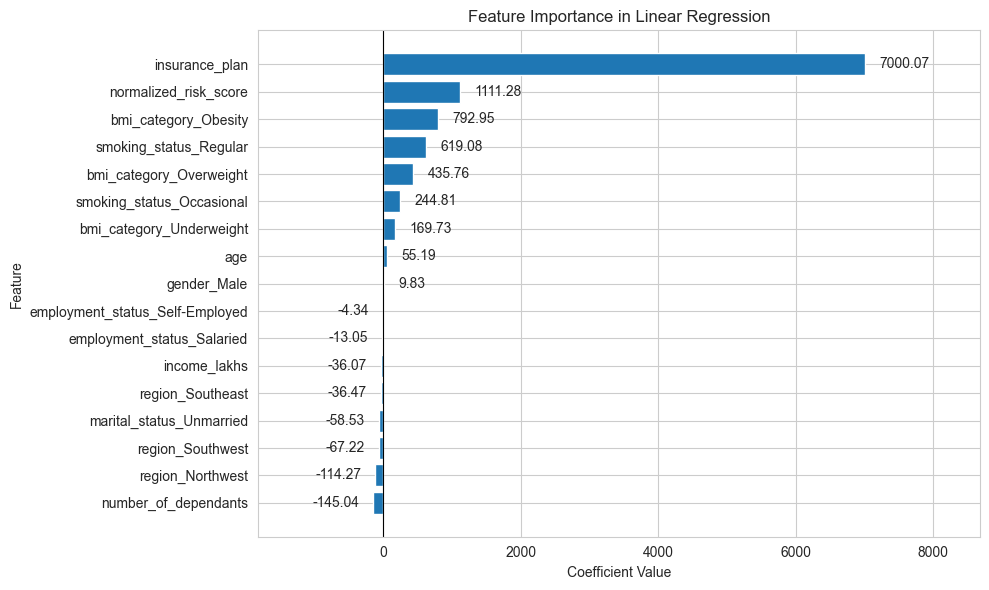

In [130]:
# Create a DataFrame of feature coefficients
coef_df = pd.DataFrame({'Feature': X_train.columns,'Coefficient': model_lr.coef_}).sort_values(by='Coefficient')

plt.figure(figsize=(10, 6))

bars = plt.barh(coef_df['Feature'],coef_df['Coefficient'])

# Add coefficient labels
offset = coef_df['Coefficient'].abs().max() * 0.03

for bar in bars:
    width = bar.get_width()

    plt.text(width + offset if width > 0 else width - offset,bar.get_y() + bar.get_height() / 2,f'{width:.2f}',va='center',
        ha='left' if width > 0 else 'right')

# Add padding on both sides
xmin = coef_df['Coefficient'].min() - offset * 8
xmax = coef_df['Coefficient'].max() + offset * 8
plt.xlim(xmin, xmax)

plt.axvline(x=0, color='black', linewidth=0.8)

plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Linear Regression')

plt.tight_layout()
plt.show()

#### **Ridge Regression Model**

In [131]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.6020466631305188, 0.6047715291063815)

In [132]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  3005573.9638324636 RMSE:  1733.6591256162394


#### **Random Forest**

In [133]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Train baseline model
model_rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)

model_rf.fit(X_train, y_train)
model_rf.score(X_test, y_test)

0.5960432876567303

In [134]:
# Predictions and evaluation
y_pred = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Regression ==> MSE:", mse_rf, "RMSE:", rmse_rf)

Random Forest Regression ==> MSE: 3071949.180151775 RMSE: 1752.6976864684266


In [135]:
# Hyperparameter tuning
model_rf = RandomForestRegressor(random_state=42)

param_grid = {'n_estimators': [100, 200, 300],'max_depth': [3, 5, 10, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

random_search = RandomizedSearchCV(estimator=model_rf,param_distributions=param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

random_search.best_score_

np.float64(0.5976371387086008)

In [136]:
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 5}

In [137]:
best_model = random_search.best_estimator_

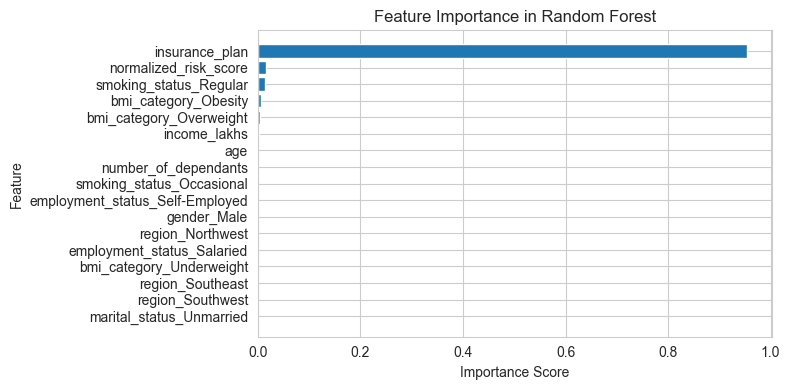

In [138]:
# Feature importance
feature_importance = best_model.feature_importances_

importance_df = pd.DataFrame({'Feature': X_train.columns,'Importance': feature_importance}).sort_values(by='Importance')

plt.figure(figsize=(8, 4))

plt.barh(importance_df['Feature'],importance_df['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest')

plt.tight_layout()
plt.show()

In [139]:
# Generate predictions using the best Random Forest model
y_pred = best_model.predict(X_test)

# Calculate prediction errors
residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

# Create a results DataFrame
results_df = pd.DataFrame({'actual': y_test,'predicted': y_pred,'diff': residuals,'diff_pct': residuals_pct})

results_df.head()

,actual,predicted,diff,diff_pct
12774,6238,6578.233461,340.233461,5.454207
14758,9462,7060.751256,-2401.248744,-25.377814
13205,5152,7063.106684,1911.106684,37.094462
14278,6988,7859.209712,871.209712,12.467225
19351,4917,6578.233461,1661.233461,33.785509


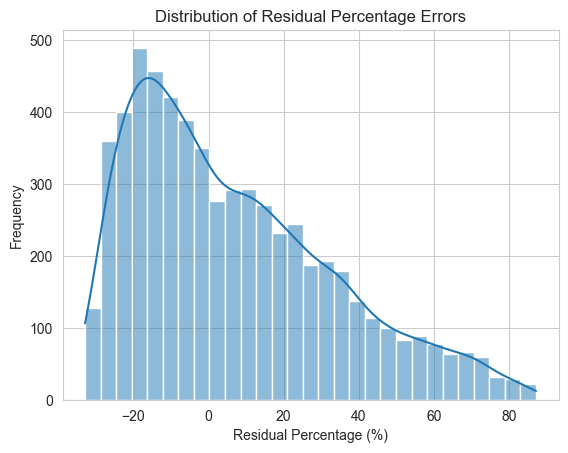

In [140]:
sns.histplot(results_df['diff_pct'], kde=True)

plt.title('Distribution of Residual Percentage Errors')
plt.xlabel('Residual Percentage (%)')
plt.ylabel('Frequency')

plt.savefig("../images/young_model_residual_errors.png", dpi=300, bbox_inches="tight")
plt.show()

In [141]:
X_test.shape

(6026, 17)

In [142]:
results_df.shape

(6026, 4)

In [143]:
# Identify predictions with large percentage errors
error_threshold = 10

extreme_results_df = results_df[
    np.abs(results_df['diff_pct']) > error_threshold]

extreme_results_df.head()

,actual,predicted,diff,diff_pct
14758,9462,7060.751256,-2401.248744,-25.377814
13205,5152,7063.106684,1911.106684,37.094462
14278,6988,7859.209712,871.209712,12.467225
19351,4917,6578.233461,1661.233461,33.785509
10622,8947,7062.210842,-1884.789158,-21.066158


In [144]:
extreme_results_df.shape

(4418, 4)

In [145]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]

In [146]:
round(extreme_errors_pct, 2)

73.32

We observe that **73.32%** of the predictions have extreme errors, suggesting the need for further analysis and corrective measures to improve model performance.

In [147]:
extreme_errors_df = X_test.loc[extreme_results_df.index]

In [148]:
extreme_errors_df.head(5)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
14758,0.285714,0.000000,0.060606,0.0,0.000000,0,0,0,1,1,0,0,0,0,1,0,1
13205,0.714286,0.333333,0.141414,0.0,0.000000,1,1,0,0,1,0,0,0,0,1,0,1
14278,0.714286,0.333333,0.222222,0.0,0.000000,1,0,1,0,1,1,0,0,0,1,0,0
19351,0.571429,0.000000,0.101010,0.0,0.000000,1,0,0,1,1,0,0,1,0,0,0,0
10622,0.428571,0.333333,0.050505,0.0,0.357143,0,0,1,0,1,0,1,0,0,0,0,0


In [149]:
results_df[abs(results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
4692,3516,6578.233461,3062.233461,87.094240
4169,3517,6578.233461,3061.233461,87.041042
12285,3532,6578.233461,3046.233461,86.246700
3652,3536,6578.233461,3042.233461,86.036014
16580,3538,6578.233461,3040.233461,85.930850
...,...,...,...,...
17689,4685,7037.802575,2352.802575,50.219906
12767,4734,7110.573288,2376.573288,50.202224
14882,4740,7115.745128,2375.745128,50.121205
5788,4857,7290.189736,2433.189736,50.096556


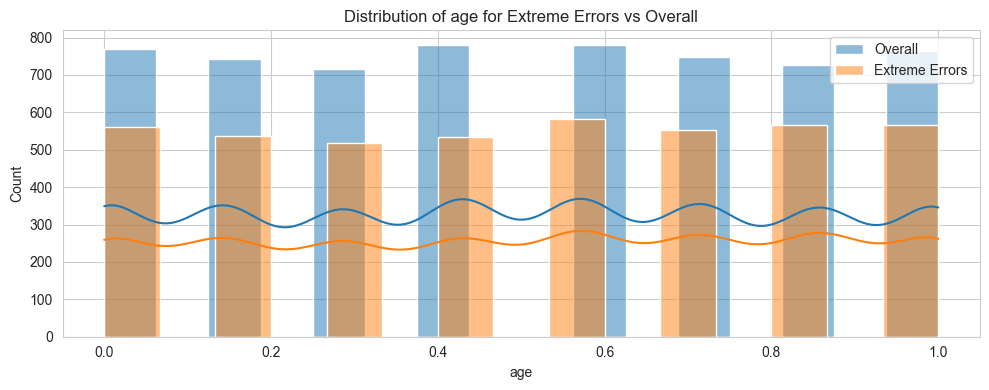

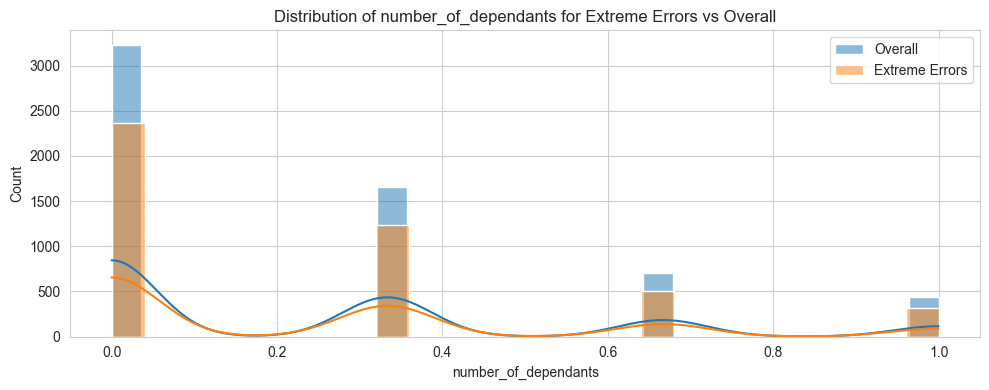

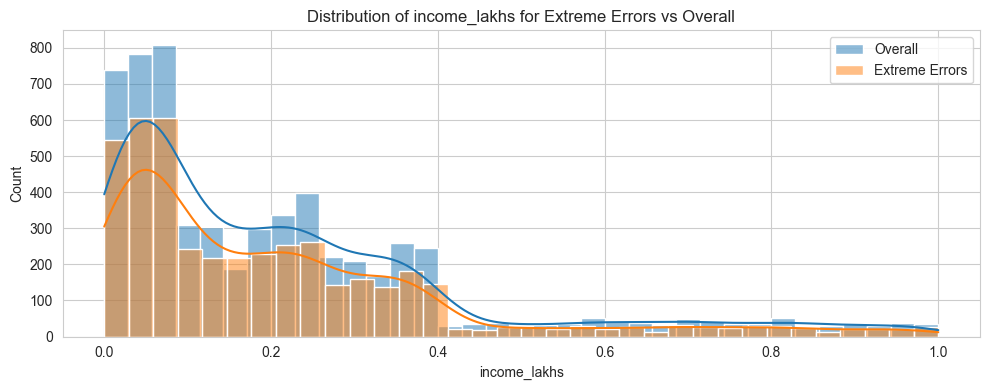

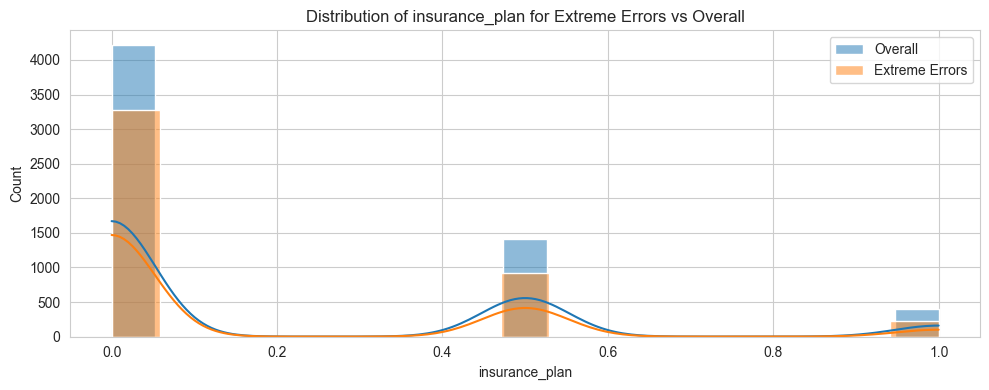

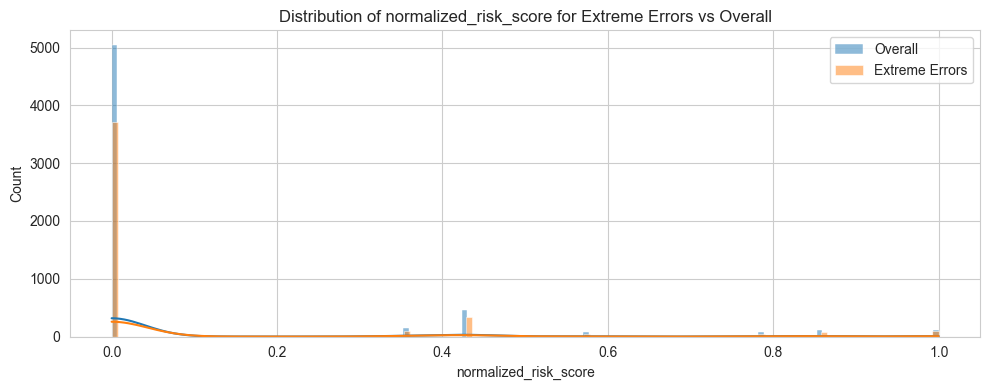

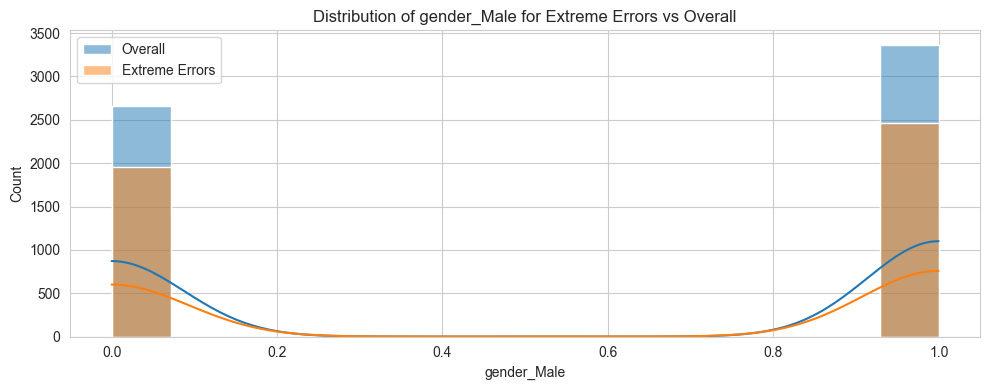

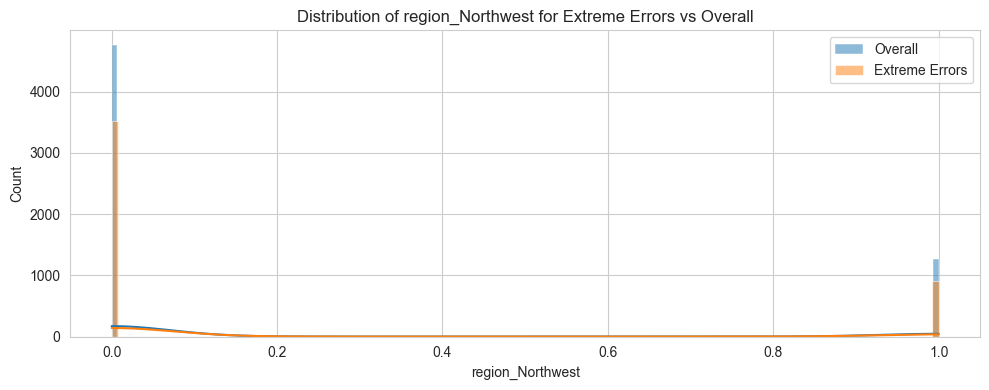

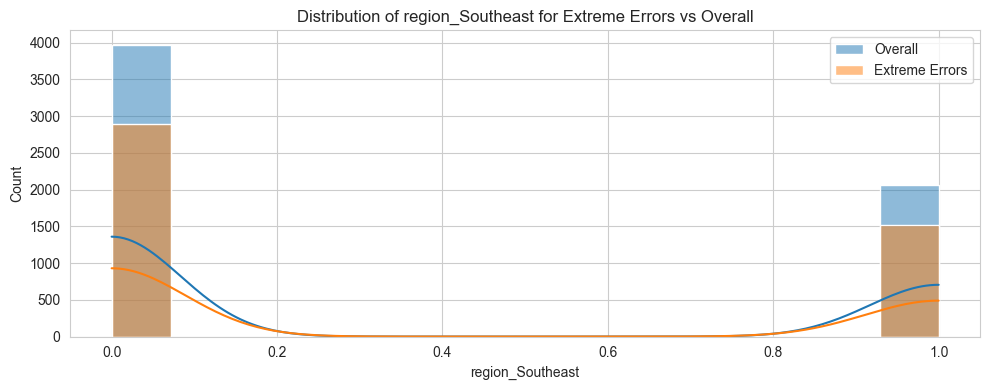

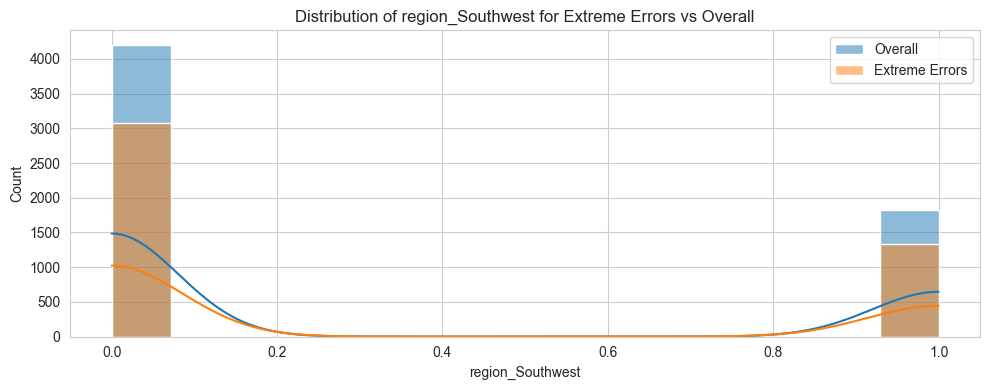

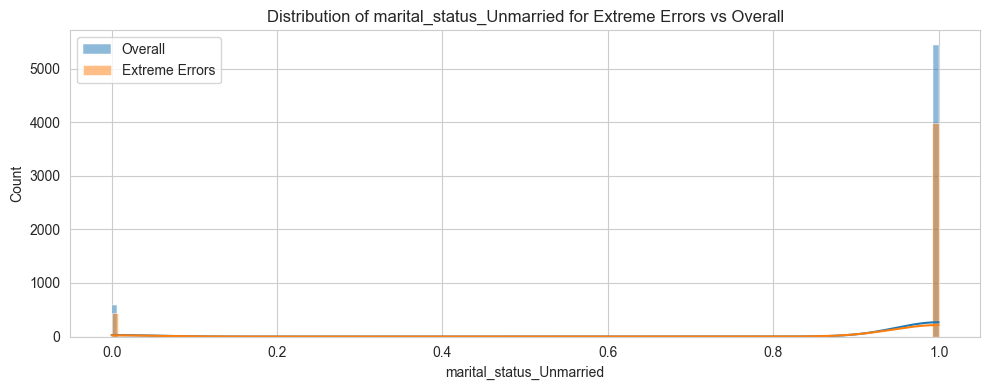

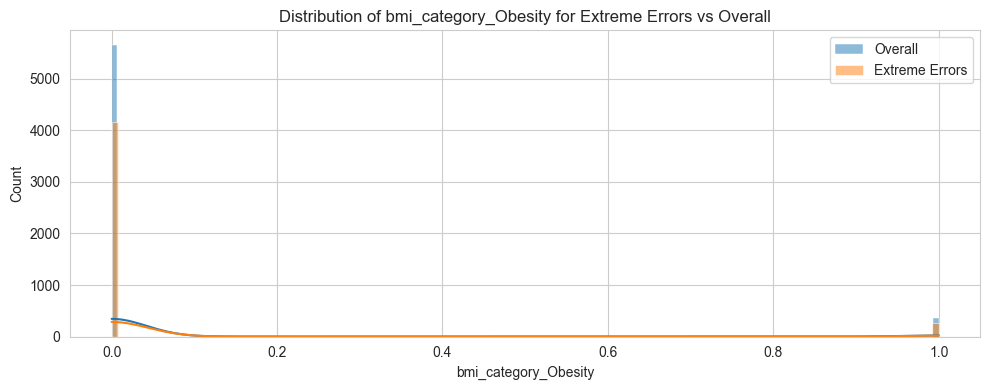

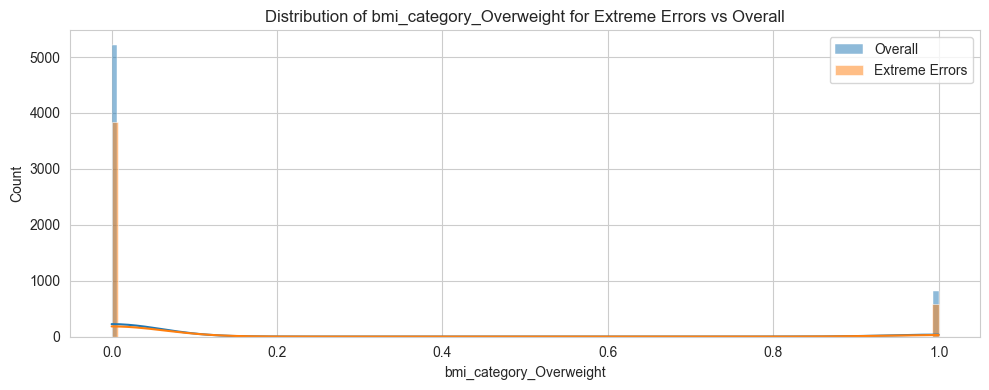

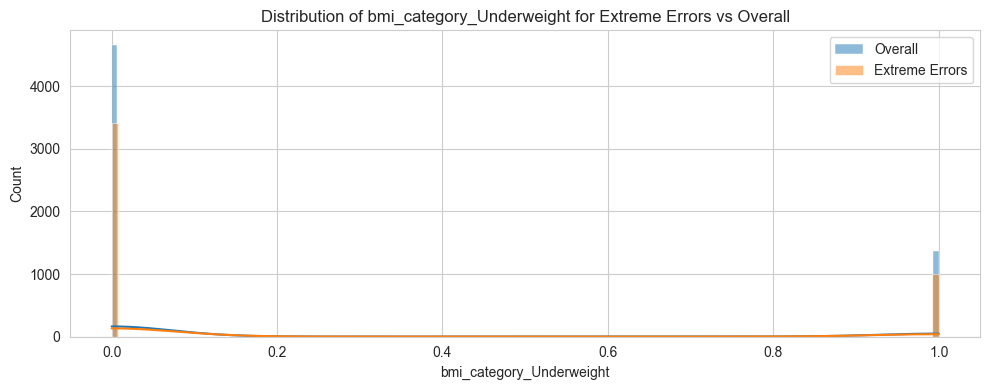

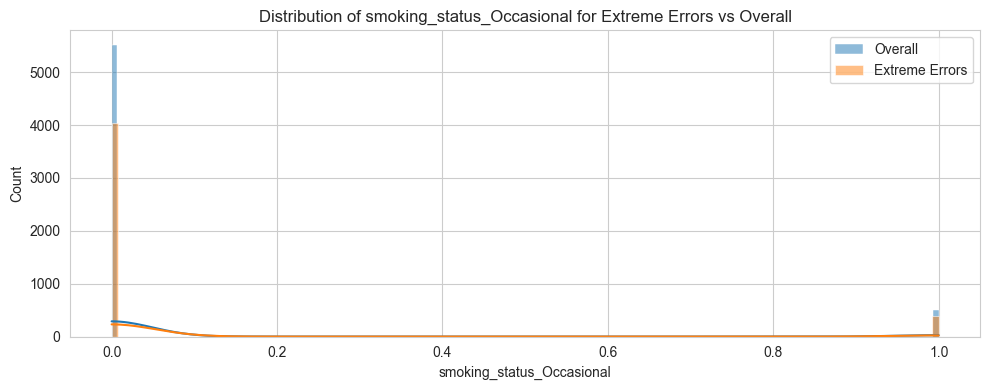

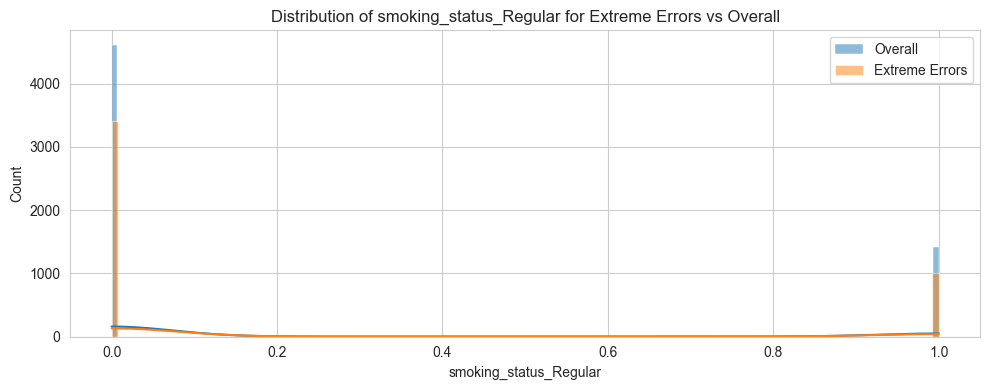

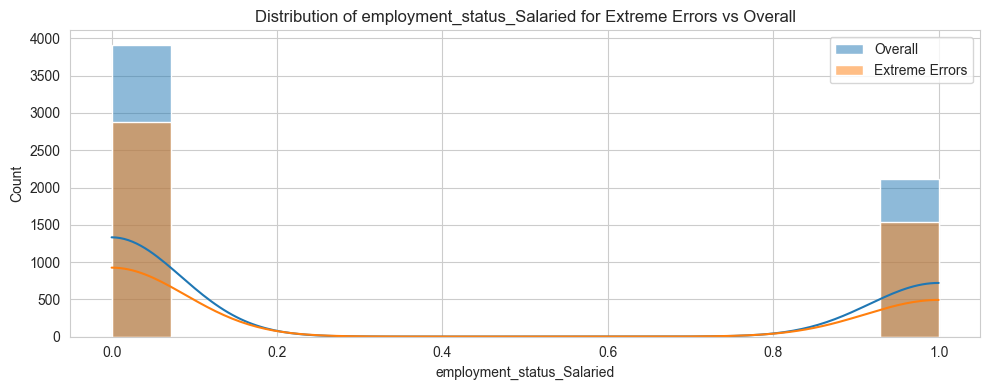

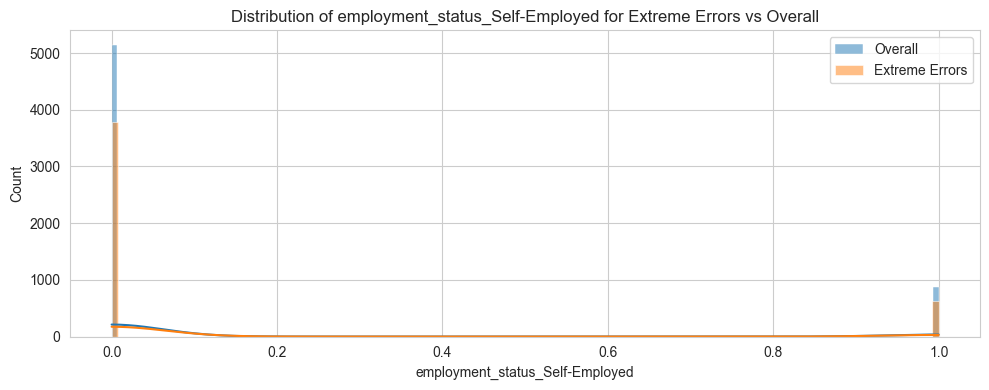

In [150]:
for feature in X_test.columns:

    plt.figure(figsize=(10, 4))

    sns.histplot(X_test[feature],label='Overall',alpha=0.5,kde=True)

    sns.histplot(extreme_errors_df[feature],label='Extreme Errors',kde=True)

    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()

    plt.tight_layout()
    plt.show()

Comparing the feature distributions of the overall test set and the extreme-error observations did not reveal any meaningful patterns or actionable insights. This suggests that the current set of features may not be sufficient to explain the large prediction errors. As a next step, we may need to collect additional relevant features from the business to improve the model's predictive performance. At this stage, further improvements appear limited by the available data.